In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [3]:

df = pd.read_csv("data/Mall_Customers.csv")


In [5]:
features = [
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[features].copy()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [7]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(
    X_scaled
)

kmeans_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

print(
    "K-Means Silhouette:",
    round(kmeans_score, 4)
)

K-Means Silhouette: 0.5547


In [9]:
hierarchical = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(
    X_scaled
)

hierarchical_score = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print(
    "Hierarchical Silhouette:",
    round(hierarchical_score, 4)
)

Hierarchical Silhouette: 0.5538


In [11]:
dbscan = DBSCAN(
    eps=0.35,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(
    X_scaled
)

In [13]:
dbscan_non_noise = (
    dbscan_labels != -1
)

dbscan_score = silhouette_score(
    X_scaled[dbscan_non_noise],
    dbscan_labels[dbscan_non_noise]
)

dbscan_noise = np.sum(
    dbscan_labels == -1
)

print(
    "DBSCAN Silhouette:",
    round(dbscan_score, 4)
)

print(
    "DBSCAN Noise:",
    dbscan_noise
)

print(
    "DBSCAN Noise Percentage:",
    round(
        dbscan_noise / len(df) * 100,
        2
    ),
    "%"
)

DBSCAN Silhouette: 0.5577
DBSCAN Noise: 23
DBSCAN Noise Percentage: 11.5 %


In [15]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

pca_kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

pca_labels = pca_kmeans.fit_predict(
    X_pca
)

pca_score = silhouette_score(
    X_pca,
    pca_labels
)

print(
    "PCA + K-Means Silhouette:",
    round(pca_score, 4)
)

PCA + K-Means Silhouette: 0.5547


In [17]:
comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical",
        "DBSCAN",
        "PCA + K-Means"
    ],
    
    "Silhouette_Score": [
        kmeans_score,
        hierarchical_score,
        dbscan_score,
        pca_score
    ]
})

comparison = comparison.sort_values(
    "Silhouette_Score",
    ascending=False
).reset_index(drop=True)

comparison

,Algorithm,Silhouette_Score
0,DBSCAN,0.557746
1,K-Means,0.554657
2,PCA + K-Means,0.554657
3,Hierarchical,0.553809


In [19]:
comparison_full = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical",
        "DBSCAN",
        "PCA + K-Means"
    ],
    
    "Clusters": [
        len(np.unique(kmeans_labels)),
        len(np.unique(hierarchical_labels)),
        len(set(dbscan_labels)) - (
            1 if -1 in dbscan_labels else 0
        ),
        len(np.unique(pca_labels))
    ],
    
    "Noise_Points": [
        0,
        0,
        dbscan_noise,
        0
    ],
    
    "Silhouette_Score": [
        kmeans_score,
        hierarchical_score,
        dbscan_score,
        pca_score
    ]
})

comparison_full = comparison_full.sort_values(
    "Silhouette_Score",
    ascending=False
).reset_index(drop=True)

comparison_full

,Algorithm,Clusters,Noise_Points,Silhouette_Score
0,DBSCAN,6,23,0.557746
1,K-Means,5,0,0.554657
2,PCA + K-Means,5,0,0.554657
3,Hierarchical,5,0,0.553809


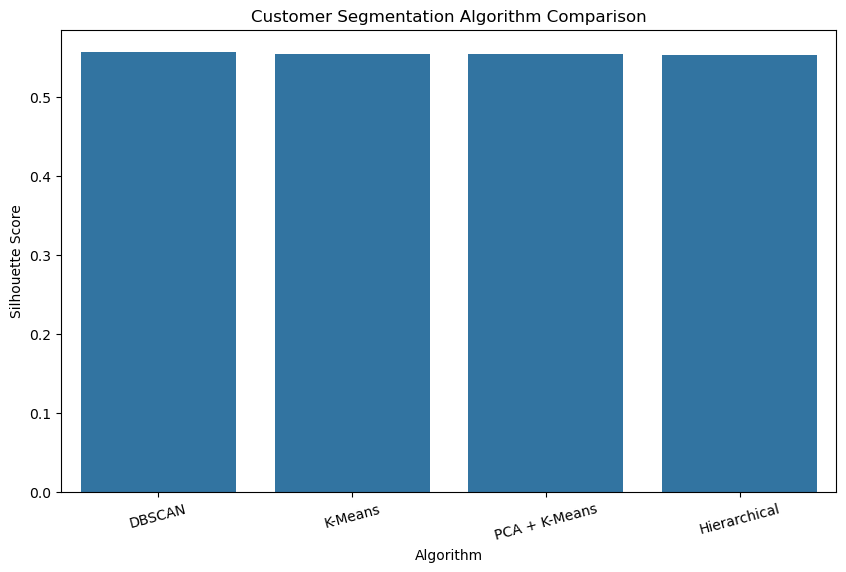

In [21]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_full,
    x="Algorithm",
    y="Silhouette_Score"
)

plt.title(
    "Customer Segmentation Algorithm Comparison"
)

plt.xlabel("Algorithm")
plt.ylabel("Silhouette Score")

plt.xticks(
    rotation=15
)

plt.show()

In [23]:
dbscan_coverage = (
    np.sum(dbscan_labels != -1)
    / len(df)
)

print(
    "DBSCAN Coverage:",
    round(dbscan_coverage * 100, 2),
    "%"
)

DBSCAN Coverage: 88.5 %


In [25]:
model_assessment = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical",
        "DBSCAN",
        "PCA + K-Means"
    ],
    
    "Silhouette": [
        kmeans_score,
        hierarchical_score,
        dbscan_score,
        pca_score
    ],
    
    "Coverage": [
        1.00,
        1.00,
        dbscan_coverage,
        1.00
    ],
    
    "Noise_Percentage": [
        0,
        0,
        dbscan_noise / len(df),
        0
    ]
})

model_assessment

,Algorithm,Silhouette,Coverage,Noise_Percentage
0,K-Means,0.554657,1.000,0.000
1,Hierarchical,0.553809,1.000,0.000
2,DBSCAN,0.557746,0.885,0.115
3,PCA + K-Means,0.554657,1.000,0.000


In [27]:
final_df = df.copy()

final_df["Customer_Segment"] = kmeans_labels

final_df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Customer_Segment
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [29]:
customer_profile = final_df.groupby(
    "Customer_Segment"
).agg(
    Customer_Count=(
        "CustomerID",
        "count"
    ),
    
    Average_Age=(
        "Age",
        "mean"
    ),
    
    Average_Income=(
        "Annual Income (k$)",
        "mean"
    ),
    
    Average_Spending=(
        "Spending Score (1-100)",
        "mean"
    )
).round(2)

customer_profile

,Customer_Count,Average_Age,Average_Income,Average_Spending
Customer_Segment,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91


In [31]:
customer_profile = final_df.groupby(
    "Customer_Segment"
).agg(
    Customer_Count=(
        "CustomerID",
        "count"
    ),
    
    Average_Age=(
        "Age",
        "mean"
    ),
    
    Average_Income=(
        "Annual Income (k$)",
        "mean"
    ),
    
    Average_Spending=(
        "Spending Score (1-100)",
        "mean"
    )
).round(2)

customer_profile

,Customer_Count,Average_Age,Average_Income,Average_Spending
Customer_Segment,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91


In [33]:
customer_profile.sort_values(
    "Average_Spending",
    ascending=False
)

,Customer_Count,Average_Age,Average_Income,Average_Spending
Customer_Segment,,,,
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
0,81,42.72,55.30,49.52
4,23,45.22,26.30,20.91
3,35,41.11,88.20,17.11


In [35]:
customer_profile

,Customer_Count,Average_Age,Average_Income,Average_Spending
Customer_Segment,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91


In [37]:
segment_names = {}

for cluster in customer_profile.index:
    
    income = customer_profile.loc[
        cluster,
        "Average_Income"
    ]
    
    spending = customer_profile.loc[
        cluster,
        "Average_Spending"
    ]
    
    if income >= 70 and spending >= 60:
        name = "High Value Customers"
        
    elif income < 70 and spending >= 60:
        name = "Young High-Spending Customers"
        
    elif income >= 70 and spending < 40:
        name = "High Income Low-Spending Customers"
        
    elif income < 50 and spending < 40:
        name = "Low Value Customers"
        
    else:
        name = "Moderate Customers"
    
    segment_names[cluster] = name

segment_names

{0: 'Moderate Customers',
 1: 'High Value Customers',
 2: 'Young High-Spending Customers',
 3: 'High Income Low-Spending Customers',
 4: 'Low Value Customers'}

In [39]:
final_df["Segment_Name"] = (
    final_df["Customer_Segment"]
    .map(segment_names)
)

final_df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Customer_Segment,Segment_Name
0,1,Male,19,15,39,4,Low Value Customers
1,2,Male,21,15,81,2,Young High-Spending Customers
2,3,Female,20,16,6,4,Low Value Customers
3,4,Female,23,16,77,2,Young High-Spending Customers
4,5,Female,31,17,40,4,Low Value Customers


In [41]:
final_segment_profile = final_df.groupby(
    "Segment_Name"
).agg(
    Customer_Count=(
        "CustomerID",
        "count"
    ),
    
    Average_Age=(
        "Age",
        "mean"
    ),
    
    Average_Income=(
        "Annual Income (k$)",
        "mean"
    ),
    
    Average_Spending=(
        "Spending Score (1-100)",
        "mean"
    )
).round(2)

final_segment_profile

,Customer_Count,Average_Age,Average_Income,Average_Spending
Segment_Name,,,,
High Income Low-Spending Customers,35,41.11,88.20,17.11
High Value Customers,39,32.69,86.54,82.13
Low Value Customers,23,45.22,26.30,20.91
Moderate Customers,81,42.72,55.30,49.52
Young High-Spending Customers,22,25.27,25.73,79.36


In [43]:
final_segment_profile.sort_values(
    "Average_Spending",
    ascending=False
)

,Customer_Count,Average_Age,Average_Income,Average_Spending
Segment_Name,,,,
High Value Customers,39,32.69,86.54,82.13
Young High-Spending Customers,22,25.27,25.73,79.36
Moderate Customers,81,42.72,55.30,49.52
Low Value Customers,23,45.22,26.30,20.91
High Income Low-Spending Customers,35,41.11,88.20,17.11


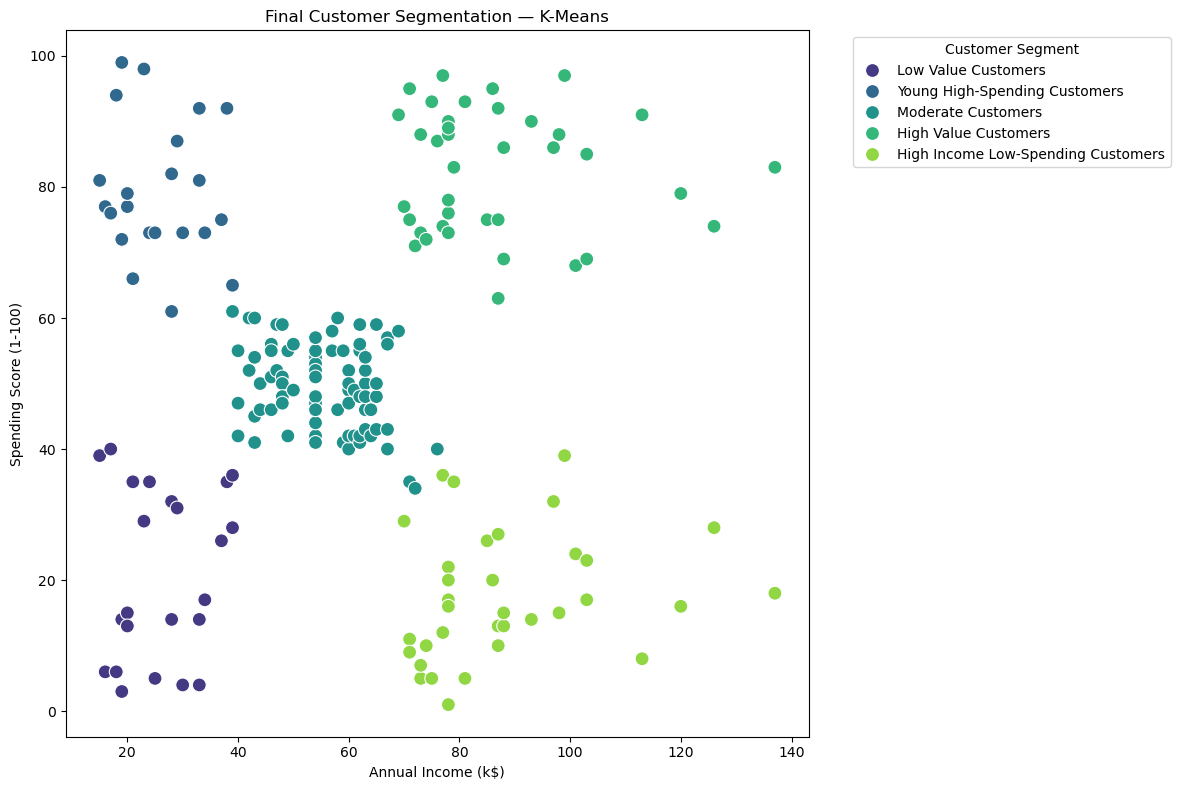

In [45]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=final_df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Segment_Name",
    palette="viridis",
    s=100
)

plt.title(
    "Final Customer Segmentation — K-Means"
)

plt.xlabel(
    "Annual Income (k$)"
)

plt.ylabel(
    "Spending Score (1-100)"
)

plt.legend(
    title="Customer Segment",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

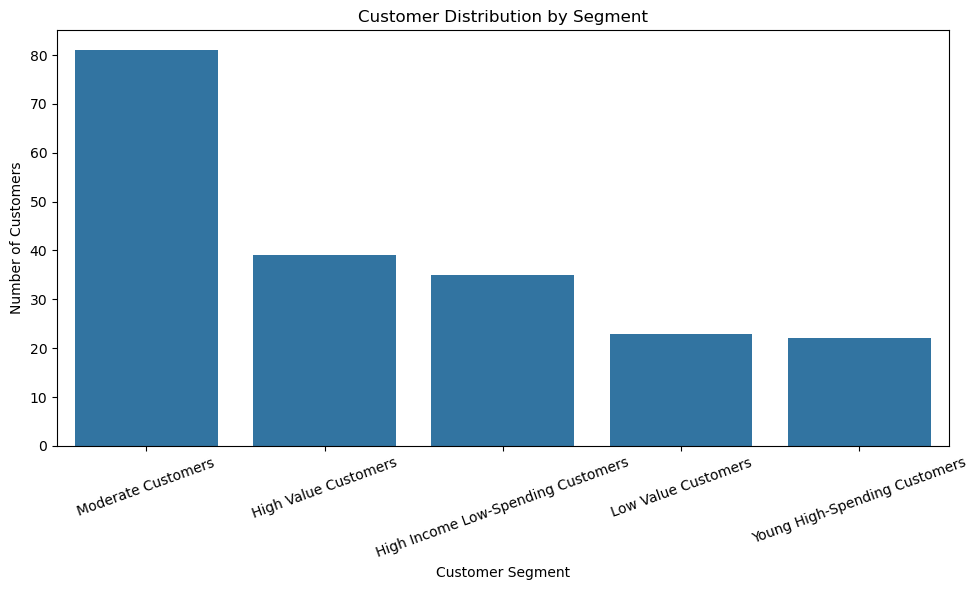

In [47]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=final_df,
    x="Segment_Name",
    order=final_df[
        "Segment_Name"
    ].value_counts().index
)

plt.title(
    "Customer Distribution by Segment"
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

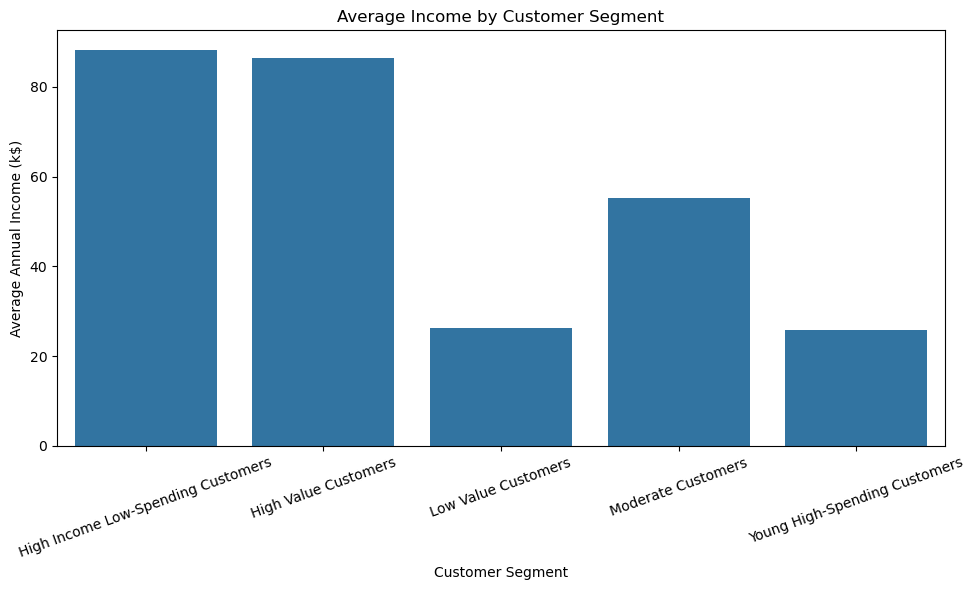

In [49]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=final_segment_profile.reset_index(),
    x="Segment_Name",
    y="Average_Income"
)

plt.title(
    "Average Income by Customer Segment"
)

plt.xlabel("Customer Segment")
plt.ylabel("Average Annual Income (k$)")

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

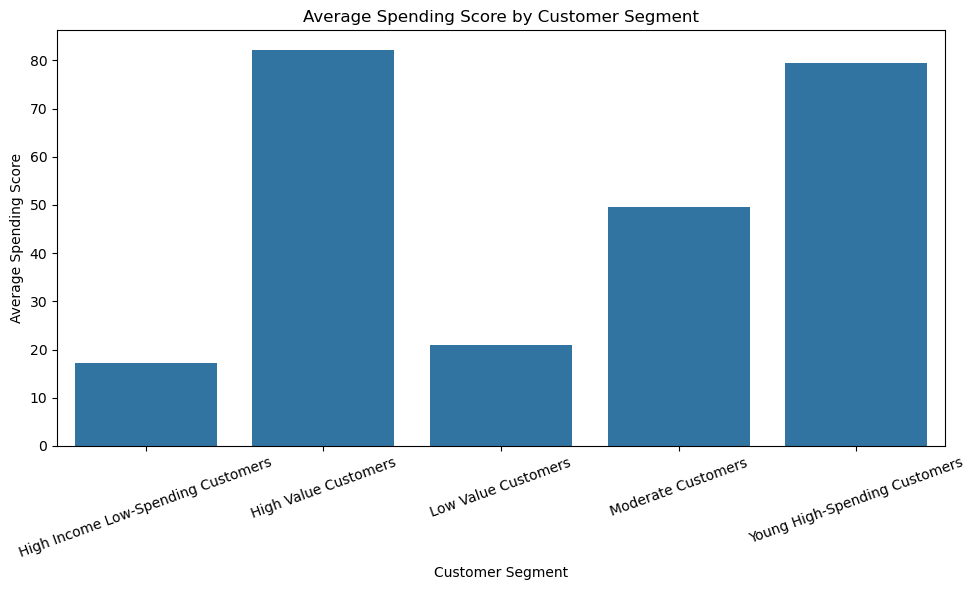

In [51]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=final_segment_profile.reset_index(),
    x="Segment_Name",
    y="Average_Spending"
)

plt.title(
    "Average Spending Score by Customer Segment"
)

plt.xlabel("Customer Segment")
plt.ylabel("Average Spending Score")

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

In [53]:
recommendations = {
    "High Value Customers":
        "Premium offers, loyalty rewards, exclusive products and VIP programs.",
    
    "Young High-Spending Customers":
        "Trendy products, personalized recommendations, social-media campaigns and limited-time offers.",
    
    "High Income Low-Spending Customers":
        "Personalized promotions, premium product demonstrations and incentives to increase engagement.",
    
    "Low Value Customers":
        "Discount campaigns, affordable bundles and introductory offers.",
    
    "Moderate Customers":
        "Cross-selling, personalized recommendations and loyalty-building campaigns."
}

In [55]:
final_segment_profile[
    "Recommended_Strategy"
] = final_segment_profile.index.map(
    recommendations
)

final_segment_profile

,Customer_Count,Average_Age,Average_Income,Average_Spending,Recommended_Strategy
Segment_Name,,,,,
High Income Low-Spending Customers,35,41.11,88.20,17.11,"Personalized promotions, premium product demon..."
High Value Customers,39,32.69,86.54,82.13,"Premium offers, loyalty rewards, exclusive pro..."
Low Value Customers,23,45.22,26.30,20.91,"Discount campaigns, affordable bundles and int..."
Moderate Customers,81,42.72,55.30,49.52,"Cross-selling, personalized recommendations an..."
Young High-Spending Customers,22,25.27,25.73,79.36,"Trendy products, personalized recommendations,..."


In [57]:
final_df.to_csv(
    "outputs/results/final_customer_segments.csv",
    index=False
)

print(
    "Final customer segmentation saved."
)

Final customer segmentation saved.


In [59]:
final_segment_profile.to_csv(
    "outputs/results/final_segment_profile.csv"
)

print(
    "Final segment profile saved."
)

Final segment profile saved.


In [61]:
comparison_full.to_csv(
    "outputs/results/final_algorithm_comparison.csv",
    index=False
)

model_assessment.to_csv(
    "outputs/results/model_assessment.csv",
    index=False
)

print(
    "Model comparison saved."
)

Model comparison saved.


In [63]:
import joblib

joblib.dump(
    kmeans,
    "models/final_kmeans_model.pkl"
)

joblib.dump(
    scaler,
    "models/final_scaler.pkl"
)

print(
    "Final K-Means model saved."
)

Final K-Means model saved.


In [65]:
import joblib

joblib.dump(
    kmeans,
    "models/final_kmeans_model.pkl"
)

joblib.dump(
    scaler,
    "models/final_scaler.pkl"
)

print(
    "Final K-Means model saved."
)

Final K-Means model saved.


In [67]:
print("=" * 70)
print("CUSTOMER SEGMENTATION — FINAL PROJECT REPORT")
print("=" * 70)

print("\nDATASET")
print("-" * 70)
print("Customers:", len(df))
print("Features used:", ", ".join(features))

print("\nMODEL PERFORMANCE")
print("-" * 70)

print(
    f"K-Means:              {kmeans_score:.4f}"
)

print(
    f"Hierarchical:          {hierarchical_score:.4f}"
)

print(
    f"DBSCAN:                {dbscan_score:.4f}"
)

print(
    f"PCA + K-Means:         {pca_score:.4f}"
)

print("\nDBSCAN")
print("-" * 70)

print(
    f"Noise customers:      {dbscan_noise}"
)

print(
    f"Noise percentage:     "
    f"{dbscan_noise / len(df) * 100:.2f}%"
)

print("\nFINAL MODEL")
print("-" * 70)
print("Primary model: K-Means")
print("Number of segments: 5")

print("\nCUSTOMER SEGMENTS")
print("-" * 70)

print(
    final_segment_profile
)

print("\nPROJECT COMPLETE")
print("=" * 70)

CUSTOMER SEGMENTATION — FINAL PROJECT REPORT

DATASET
----------------------------------------------------------------------
Customers: 200
Features used: Annual Income (k$), Spending Score (1-100)

MODEL PERFORMANCE
----------------------------------------------------------------------
K-Means:              0.5547
Hierarchical:          0.5538
DBSCAN:                0.5577
PCA + K-Means:         0.5547

DBSCAN
----------------------------------------------------------------------
Noise customers:      23
Noise percentage:     11.50%

FINAL MODEL
----------------------------------------------------------------------
Primary model: K-Means
Number of segments: 5

CUSTOMER SEGMENTS
----------------------------------------------------------------------
                                    Customer_Count  Average_Age  \
Segment_Name                                                      
High Income Low-Spending Customers              35        41.11   
High Value Customers                    